# Lab 6: Полный протокол — ARQ и адаптивный выбор режима

**Цель**: собрать из физических уровней Labs 3-5 полноценный протокол канального уровня:
кадрирование, автоматический запрос на повтор (ARQ), оценка качества канала и адаптивный выбор режима передачи.

**Что исследуем**:
1. Формат кадра протокола (преамбула, длина, payload, CRC)
2. ARQ Stop-and-Wait: ретрансляции, таймауты, useful throughput (goodput)
3. Оценка SNR канала probe-пакетом (двойное зондирование)
4. Адаптивный выбор режима: FSK / MFSK / OFDM QPSK / 16-QAM / 64-QAM
5. Полный цикл «файл по воздуху»: RS-FEC + ARQ + выбранный режим
6. Узкополосная помеха (jammer): FSK vs OFDM — частотное разнесение

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('common'))
import numpy as np
import matplotlib.pyplot as plt
import modem_lib as m
plt.rcParams['figure.dpi'] = 100
FS = m.FS
print(f'Библиотека загружена. FS = {FS} Гц')

Библиотека загружена. FS = 48000 Гц


## 6.1 Формат кадра протокола

Протокол канального уровня поверх физики Labs 3-5:

```
+-----------+--------+----------+---------+--------+
| PREAMBLE  |  LEN   | PAYLOAD  |  CRC16  |        |
| 16 бит    | 8 бит  | 8-255 Б  | 16 бит  |        |
+-----------+--------+----------+---------+--------+
              ^                ^
              |                +-- [SEQ:1 Б][ДАННЫЕ] -- ARQ нумерует кадры
              +--- длина payload в байтах
```

- **Preamble** `1010...` — синхронизация и детектирование начала кадра
- **CRC16** — обнаружение ошибок (ARQ решает, повторять ли кадр)
- **SEQ** — номер кадра: приёмник отбрасывает дубли ретрансляций
- **ACK-кадр**: payload = `b'A' + seq` — подтверждение от приёмника

RS-FEC из Lab 4 применяется к данным ДО нарезки на кадры.

Кадр: 112 бит -> seq=7, data=b'HELLO', ok=True
ACK : 80 бит -> распознан: True


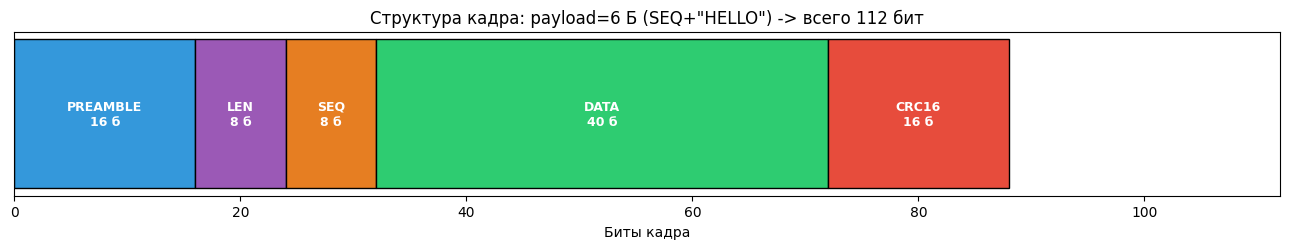

In [2]:
def frame_encode(payload: bytes, seq: int) -> str:
    return m.packet_encode(bytes([seq]) + payload)

def frame_decode(bits: str):
    d = m.packet_decode(bits)
    if d['found'] and d['crc_ok'] and len(d['payload']) >= 1:
        return {'seq': d['payload'][0], 'data': d['payload'][1:], 'ok': True}
    return {'ok': False}

def ack_encode(seq: int) -> str:
    return m.packet_encode(b'A' + bytes([seq]))

def ack_decode(bits: str, seq: int) -> bool:
    d = m.packet_decode(bits)
    return bool(d['found'] and d['crc_ok'] and d['payload'] == b'A' + bytes([seq]))

# демонстрация: кадр и ACK
bits = frame_encode(b'HELLO', seq=7)
d = frame_decode(bits)
print(f'Кадр: {len(bits)} бит -> seq={d["seq"]}, data={d["data"]}, ok={d["ok"]}')
abits = ack_encode(7)
print(f'ACK : {len(abits)} бит -> распознан: {ack_decode(abits, 7)}')

# визуализация структуры кадра
payload = bytes([7]) + b'HELLO'
bits = m.packet_encode(payload)
fig, ax = plt.subplots(figsize=(13, 2.6))
seg = [('PREAMBLE', 16, '#3498db'), ('LEN', 8, '#9b59b6'), ('SEQ', 8, '#e67e22'),
       ('DATA', (len(payload)-1)*8, '#2ecc71'), ('CRC16', 16, '#e74c3c')]
x = 0
for name, n, c in seg:
    ax.barh(0, n, left=x, color=c, edgecolor='k', height=0.6)
    ax.text(x + n/2, 0, f'{name}\n{n} б', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    x += n
ax.set_xlim(0, len(bits)); ax.set_yticks([])
ax.set_xlabel('Биты кадра'); ax.set_title(f'Структура кадра: payload=6 Б (SEQ+"HELLO") -> всего {len(bits)} бит')
plt.tight_layout(); plt.show()

## 6.2 ARQ Stop-and-Wait: надёжность ценой времени

**Алгоритм**: передатчик шлёт кадр и ждёт ACK. Если ACK не пришёл за таймаут — повторяет.
Приёмник при CRC-ошибке молчит (или шлёт NACK), при дубле — повторно подтверждает, но данные не дублирует.

Смоделируем канал Монте-Карло: вероятность ошибки кадра из измеренных BER-кривых Labs 3/5:
- FER = 1 - (1 - BER)^N_бит
- ретрансляции ~ геометрическое распределение

Считаем **goodput** = полезные биты / полное время (кадры + ACK + таймауты).

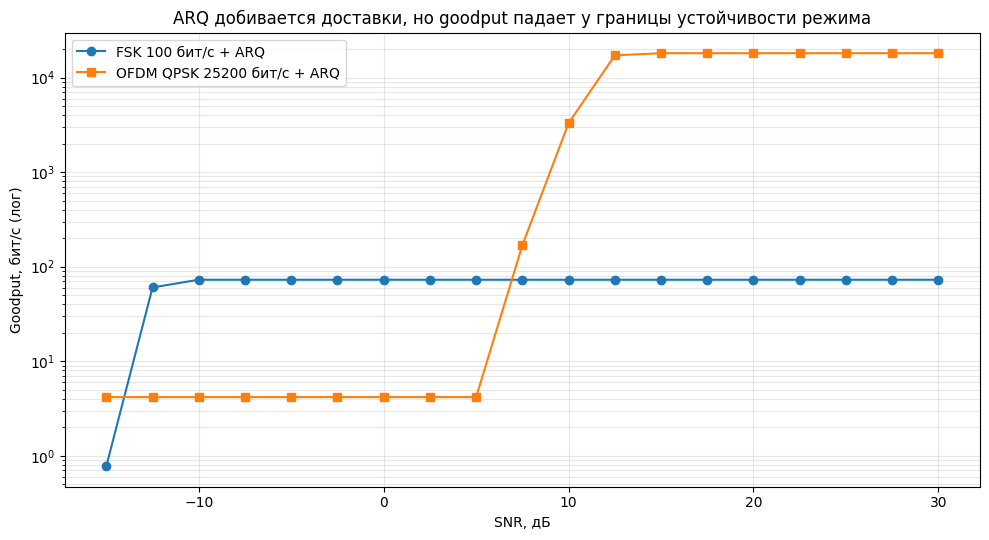

  SNR=-15.0 дБ: FSK goodput=     0.8 бит/с, QPSK goodput=      4.2 бит/с
  SNR= -5.0 дБ: FSK goodput=    72.7 бит/с, QPSK goodput=      4.2 бит/с
  SNR=  5.0 дБ: FSK goodput=    72.7 бит/с, QPSK goodput=      4.2 бит/с
  SNR= 15.0 дБ: FSK goodput=    72.7 бит/с, QPSK goodput=  18081.2 бит/с
  SNR= 25.0 дБ: FSK goodput=    72.7 бит/с, QPSK goodput=  18081.2 бит/с


In [3]:
# измеренные BER-кривые из Labs 3/5 (SNR -> BER)
# FSK: сырые биты без ошибок вплоть до -10 дБ, деградация лишь при -12..-15 (Lab 3)
BER_FSK  = {30:1e-6, 20:1e-6, 15:1e-6, 10:1e-6, 5:1e-6, 0:1e-6, -5:1e-6, -10:1e-6, -12:2e-4, -15:0.013}
BER_QPSK = {30:1e-6, 25:1e-6, 20:1e-6, 15:1e-6, 10:0.002, 5:0.055, 0:0.208}

def ber_at(curve, snr):
    xs = sorted(curve)
    if snr >= xs[-1]: return curve[xs[-1]]
    if snr <= xs[0]:  return curve[xs[0]]
    for a, b in zip(xs[:-1], xs[1:]):
        if a <= snr <= b:
            la, lb = np.log10(curve[a] + 1e-12), np.log10(curve[b] + 1e-12)
            return 10 ** (la + (lb - la) * (snr - a) / (b - a))

PAYLOAD_B = 32            # байт полезных данных в кадре
OVERHEAD = 16 + 8 + 8 + 16  # preamble+len+seq+crc = 48 бит
ACK_BITS = 48             # preamble+len+'A'+seq+crc

def arq_goodput(snr, ber_curve, bitrate, max_retx=10, trials=400, seed=0):
    rng = np.random.default_rng(seed)
    frame_bits = PAYLOAD_B * 8 + OVERHEAD
    fer = 1 - (1 - ber_at(ber_curve, snr)) ** frame_bits
    fer = min(fer, 0.999)
    t_frame = frame_bits / bitrate
    t_ack = ACK_BITS / bitrate
    t_timeout = t_frame + t_ack + 0.05  # ждём кадр+ack+запас
    tot_bits, tot_time = 0, 0.0
    for _ in range(trials):
        g = rng.geometric(1 - fer)
        if g > max_retx + 1:
            # кадр НЕ доставлен за max_retx+1 попыток: время потрачено, биты не засчитаны
            tries = max_retx + 1
            tot_time += tries * t_frame + (tries - 1) * t_timeout
        else:
            tries = g
            tot_bits += PAYLOAD_B * 8
            tot_time += tries * t_frame + (tries - 1) * t_timeout + t_ack
    return tot_bits / tot_time, fer

snr_grid = np.linspace(-15, 30, 19)
gp_fsk  = [arq_goodput(s, BER_FSK, 100.0, seed=1)[0] for s in snr_grid]
gp_qpsk = [arq_goodput(s, BER_QPSK, 25200.0, seed=2)[0] for s in snr_grid]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.semilogy(snr_grid, np.array(gp_fsk) + 1e-3, 'o-', label='FSK 100 бит/с + ARQ')
ax.semilogy(snr_grid, np.array(gp_qpsk) + 1e-3, 's-', label='OFDM QPSK 25200 бит/с + ARQ')
ax.set_xlabel('SNR, дБ'); ax.set_ylabel('Goodput, бит/с (лог)')
ax.set_title('ARQ добивается доставки, но goodput падает у границы устойчивости режима')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()
for s, gf, gq in zip(snr_grid[::4], gp_fsk[::4], gp_qpsk[::4]):
    print(f'  SNR={s:5.1f} дБ: FSK goodput={gf:8.1f} бит/с, QPSK goodput={gq:9.1f} бит/с')

## 6.3 Оценка канала: probe-пакет с двойным зондированием

Адаптивному модему нужно знать SNR канала. Метод: шлём **один и тот же** зонд дважды.
- сумма половин ≈ чистый сигнал × 2
- разность половин ≈ чистый шум × 2

SNR_est = P(сумма) / P(разность). Проверим точность оценки на диапазоне 0..30 дБ.

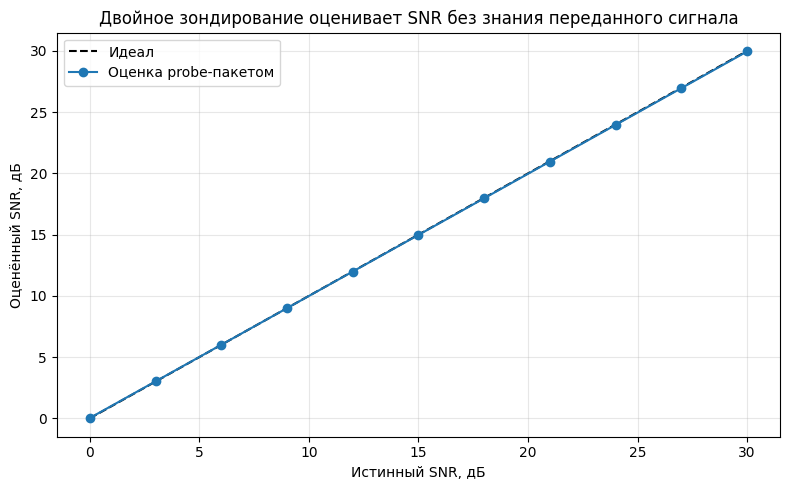

SNR true -> est: 0:0.0, 3:3.0, 6:6.0, 9:9.0, 12:12.0, 15:15.0, 18:18.0, 21:21.0, 24:24.0, 27:27.0, 30:30.0


In [4]:
def probe_estimate(snr_true, seed=0):
    probe = m.generate_chirp(500, 4000, 0.02)
    rx = m.simulate_channel(np.concatenate([probe, probe]), snr_db=snr_true, reverb_amount=0.0, seed=seed)
    a, b = rx[:len(probe)].astype(np.float64), rx[len(probe):].astype(np.float64)
    p_sum = np.mean(((a + b) / 2) ** 2)   # = P_sig + P_noise/2
    p_dif = np.mean(((a - b) / 2) ** 2)   # = P_noise/2
    p_sig = max(p_sum - p_dif, 1e-12)
    return 10 * np.log10(p_sig / (2 * p_dif))  # p_dif = P_noise/2

snr_true = np.arange(0, 31, 3)
est = [np.mean([probe_estimate(s, seed=k) for k in range(5)]) for s in snr_true]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(snr_true, snr_true, 'k--', label='Идеал')
ax.plot(snr_true, est, 'o-', label='Оценка probe-пакетом')
ax.set_xlabel('Истинный SNR, дБ'); ax.set_ylabel('Оценённый SNR, дБ')
ax.set_title('Двойное зондирование оценивает SNR без знания переданного сигнала')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('SNR true -> est: ' + ', '.join(f'{s}:{e:.1f}' for s, e in zip(snr_true, est)))

## 6.4 Адаптивный выбор режима

Таблица режимов из накопленных измерений (Labs 3-5):

| Режим | Битрейт | BER-кривая | Рабочая зона |
|-------|---------|-----------|--------------|
| FSK 100 бод | 100 бит/с | устойчив до −10 дБ | плохой канал |
| MFSK-8 | 300 бит/с | устойчива до −10 дБ; ниже −10 чуть хуже FSK (0.04 @ −15 дБ) | ниже среднего |
| OFDM QPSK | 25200 бит/с | BER<0.001 при ≥10 дБ | хороший |
| OFDM 16-QAM | 50400 бит/с | BER<0.001 при ≥20 дБ | отличный |
| OFDM 64-QAM | 75600 бит/с | BER<0.001 при ≥25 дБ | идеальный |

Стратегия: по оценённому SNR выбираем режим с максимальным goodput после ARQ.

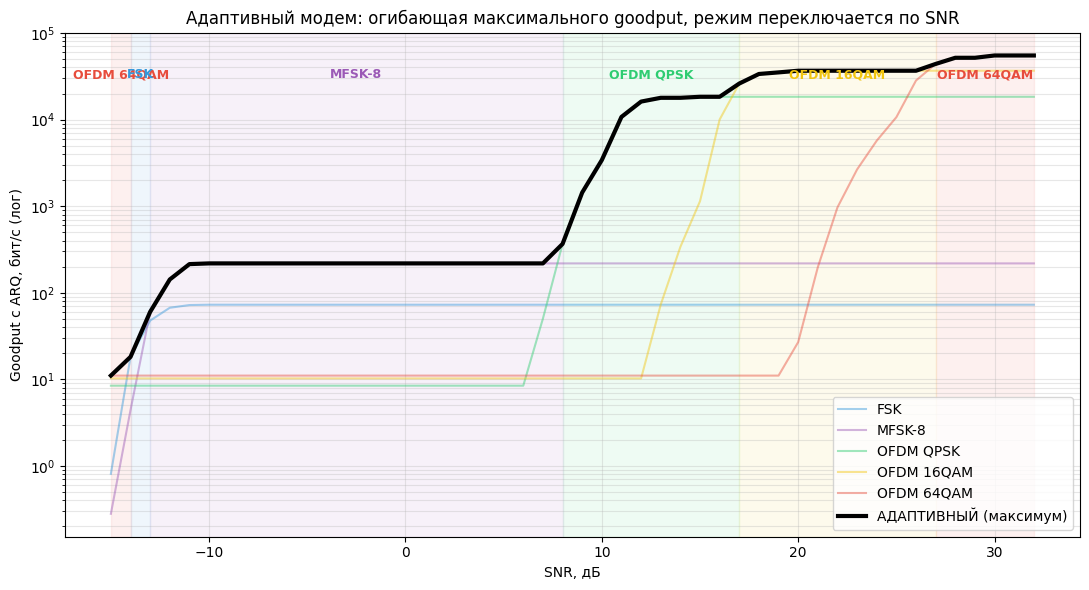

Точки переключения режимов:
  OFDM 64QAM -> FSK при SNR ≈ -14.0 дБ
  FSK -> MFSK-8 при SNR ≈ -13.0 дБ
  MFSK-8 -> OFDM QPSK при SNR ≈ 8.0 дБ
  OFDM QPSK -> OFDM 16QAM при SNR ≈ 17.0 дБ
  OFDM 16QAM -> OFDM 64QAM при SNR ≈ 27.0 дБ


In [5]:
MODES = [
    ('FSK',        100.0,   {30:1e-6, 20:1e-6, 15:1e-6, 10:1e-6, 5:1e-6, 0:1e-6, -5:1e-6, -10:1e-6, -12:2e-4, -15:0.013}),
    ('MFSK-8',     300.0,   {30:1e-6, 20:1e-6, 15:1e-6, 10:1e-6, 5:1e-6, 0:1e-6, -5:1e-6, -10:1e-6, -12:8e-4, -15:0.038}),
    ('OFDM QPSK',  25200.0, {30:1e-6, 25:1e-6, 20:1e-6, 15:1e-6, 10:0.002, 5:0.055, 0:0.208}),
    ('OFDM 16QAM', 50400.0, {30:1e-6, 25:1e-6, 20:1e-6, 15:0.005, 10:0.066, 5:0.182, 0:0.310}),
    ('OFDM 64QAM', 75600.0, {30:1e-6, 25:0.001, 20:0.018, 15:0.085, 10:0.190, 5:0.283, 0:0.383}),
]

def best_mode(snr):
    scores = [(arq_goodput(snr, curve, br, trials=200, seed=5)[0], name) for name, br, curve in MODES]
    scores.sort(reverse=True)
    return scores[0][1], scores[0][0]

snr_grid = np.linspace(-15, 32, 48)
curves = {}
for name, br, curve in MODES:
    curves[name] = [arq_goodput(s, curve, br, trials=200, seed=5)[0] for s in snr_grid]
adaptive = [max(curves[n][i] for n in curves) for i in range(len(snr_grid))]
chosen = [max(curves, key=lambda n: curves[n][i]) for i in range(len(snr_grid))]

fig, ax = plt.subplots(figsize=(11, 6))
colors = {'FSK': '#3498db', 'MFSK-8': '#9b59b6', 'OFDM QPSK': '#2ecc71', 'OFDM 16QAM': '#f1c40f', 'OFDM 64QAM': '#e74c3c'}
for name in curves:
    ax.semilogy(snr_grid, np.array(curves[name]) + 1e-3, '-', color=colors[name], alpha=0.45, label=name)
ax.semilogy(snr_grid, np.array(adaptive) + 1e-3, 'k-', lw=3, label='АДАПТИВНЫЙ (максимум)')
# подсветка зон переключения
prev, start = chosen[0], snr_grid[0]
for c, s in list(zip(chosen, snr_grid))[1:] + [(None, snr_grid[-1])]:
    if c != prev:
        ax.axvspan(start, s, color=colors[prev], alpha=0.08)
        ax.text((start + s) / 2, 3e4, prev, ha='center', fontsize=9, color=colors[prev], fontweight='bold')
        prev, start = c, s
ax.set_xlabel('SNR, дБ'); ax.set_ylabel('Goodput с ARQ, бит/с (лог)')
ax.set_title('Адаптивный модем: огибающая максимального goodput, режим переключается по SNR')
ax.legend(loc='lower right'); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()
sw = []
prev = chosen[0]
for c, s in zip(chosen, snr_grid):
    if c != prev:
        sw.append((prev, c, s)); prev = c
print('Точки переключения режимов:')
for a, b, s in sw:
    print(f'  {a} -> {b} при SNR ≈ {s:.1f} дБ')

## 6.5 Полный цикл: «файл по воздуху» с RS-FEC и ARQ

Собираем всё: файл → RS+interleave → нарезка на кадры → адаптивный режим → ARQ → сборка → RS-декодирование.
Передачу ведём **настоящими сигналами** через `simulate_channel`, каждая попытка — реальная модуляция/демодуляция.
Канал: SNR=12 дБ, лёгкая реверберация 0.02 — адаптер должен выбрать OFDM QPSK.

Probe: SNR ≈ 12.1 дБ -> адаптер выбрал: OFDM QPSK (ожид. goodput 16528 бит/с)
Файл 96 Б -> RS+interleave = 136 Б -> 5 кадров по 32 Б
Кадров доставлено: 5/5, всего попыток: 5 (1.00 на кадр)
RS-декодирование: ok=True
ФАЙЛ СОВПАЛ: True
Полезных бит: 768, попыток: 5 -> эффективный goodput ≈ 9600 бит/с


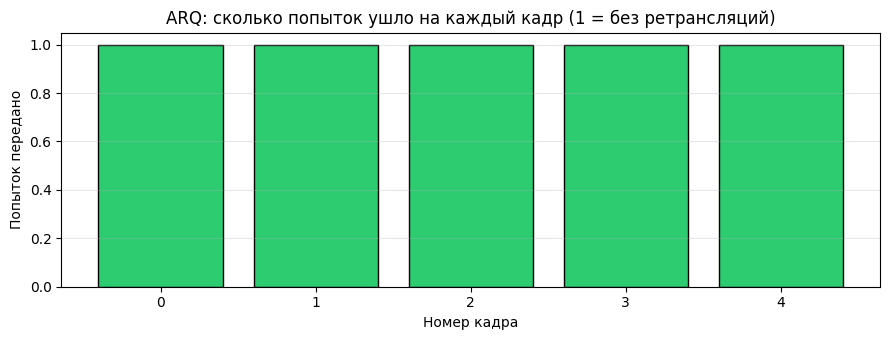

In [6]:
snr_est = probe_estimate(12.0, seed=7)
mode_name, mode_gp = best_mode(snr_est)
print(f'Probe: SNR ≈ {snr_est:.1f} дБ -> адаптер выбрал: {mode_name} (ожид. goodput {mode_gp:.0f} бит/с)')

cfg = m.OFDMConfig(fft_size=128, cp_len=32, num_data_carriers=48, carrier_start=2)
MARK, SPACE, BAUD = 1200.0, 2200.0, 100.0

def ofdm_recv(ch, cfg, sig_len):
    # грубый поиск Schmidl-Cox + точная корреляция с известной преамбулой (окно +-8)
    pre = m.ofdm_sync_preamble(cfg)
    sym = cfg.fft_size + cfg.cp_len
    M, sc = m.schmidl_cox_sync(ch, cfg)
    lo = max(0, sc - 8)
    seg = ch[lo:sc + 8 + len(pre)]
    c = np.correlate(seg, pre, mode='valid')
    start = lo + int(np.argmax(np.abs(c))) + len(pre)
    n_sym = int(np.floor(sig_len / sym))
    body = ch[start:start + n_sym * sym]
    if len(body) < sym:
        return ''
    rx, _ = m.ofdm_demodulate(body, cfg, equalize=True)
    return rx

def tx_rx_frame(payload, seq, snr, seed, mode='OFDM QPSK'):
    bits = frame_encode(payload, seq)
    if mode.startswith('OFDM'):
        sig = m.ofdm_modulate(bits, cfg)
        pre = m.ofdm_sync_preamble(cfg)
        frame = np.concatenate([pre, sig])
        ch = m.simulate_channel(frame, snr_db=snr, reverb_amount=0.02, seed=seed)
        rx = ofdm_recv(ch, cfg, len(sig))
        return frame_decode(rx)
    chirp = m.generate_chirp(200, 4000, 0.05)
    sig = m.generate_fsk(bits, MARK, SPACE, BAUD, continuous_phase=True)
    frame = np.concatenate([chirp, sig])
    ch = m.simulate_channel(frame, snr_db=snr, reverb_amount=0.0, seed=seed)
    corr, peak, _ = m.cross_correlate(ch, chirp)
    rx, _ = m.fsk_demodulate(ch[peak + len(chirp):], MARK, SPACE, BAUD)
    return frame_decode(rx)

# файл: 96 байт -> RS(nsym=10, блоки по 25 Б) + interleave -> нарезка по 32 Б
file_data = bytes((i * 37 + 11) % 256 for i in range(96))
NSYM, BDATA = 10, 25
blocks = [m.rs_encode(file_data[i*BDATA:(i+1)*BDATA], NSYM) for i in range(4)]
coded = m.interleave(b''.join(blocks), rows=4)
# последний кадр добиваем нулями до 32 Б; при сборке обрежем до len(coded)
frames = [coded[i:i+PAYLOAD_B] + bytes(PAYLOAD_B - len(coded[i:i+PAYLOAD_B])) for i in range(0, len(coded), PAYLOAD_B)]
print(f'Файл 96 Б -> RS+interleave = {len(coded)} Б -> {len(frames)} кадров по {PAYLOAD_B} Б')

# ARQ Stop-and-Wait на реальных сигналах
MAX_RETX = 6
log, received = [], {}
for i, fr in enumerate(frames):
    for attempt in range(1, MAX_RETX + 1):
        d = tx_rx_frame(fr, seq=i, snr=12.0, seed=1000 * i + attempt, mode=mode_name)
        if d['ok'] and d['seq'] == i:
            log.append((i, attempt, True)); received[i] = d['data']; break
        log.append((i, attempt, False))
    else:
        received[i] = None

n_ok = sum(1 for v in received.values() if v is not None)
n_att = len(log)
print(f'Кадров доставлено: {n_ok}/{len(frames)}, всего попыток: {n_att} ({n_att/len(frames):.2f} на кадр)')

if n_ok == len(frames):
    rx_coded = b''.join(received[i] for i in range(len(frames)))[:len(coded)]
    rx_blocks_bytes = m.deinterleave(rx_coded, rows=4, original_len=4 * (BDATA + NSYM))
    rec = b''
    ok_all = True
    for i in range(4):
        dec, nerr = m.rs_decode(rx_blocks_bytes[i*(BDATA+NSYM):(i+1)*(BDATA+NSYM)], NSYM)
        ok_all &= nerr >= 0
        rec += dec
    print(f'RS-декодирование: ok={ok_all}')
    print(f'ФАЙЛ СОВПАЛ: {rec == file_data}')
    t_frame = (128 + 4 * 160) / FS  # преамбула + 4 OFDM-символа QPSK
    eff = 96 * 8 / (n_att * t_frame)
    print(f'Полезных бит: {96*8}, попыток: {n_att} -> эффективный goodput ≈ {eff:.0f} бит/с')

fig, ax = plt.subplots(figsize=(9, 3.5))
att = [l[1] for l in log if l[2] or l[1] == MAX_RETX]
ax.bar(range(len(frames)), [sum(1 for l in log if l[0] == i) for i in range(len(frames))], color='#2ecc71', edgecolor='k')
ax.set_xlabel('Номер кадра'); ax.set_ylabel('Попыток передано')
ax.set_title('ARQ: сколько попыток ушло на каждый кадр (1 = без ретрансляций)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 6.6 Узкополосная помеха (jammer): FSK против OFDM

Ставим мощный тон-глушитель:
- **FSK**: прямо на mark-частоту 1200 Гц — модем слепнет полностью
- **OFDM**: на одну из 42 несущих — страдают символы только этой несущей (≈1/42 данных)

Это частотное разнесение: OFDM превращает тотальную потерю в локальные стирания, которые добивает RS-FEC.

FSK + jammer@1200 Гц: найден=False, CRC ok=False
OFDM + jammer@7500 Гц (k=20): BER=0.0048, CRC ok=False, RS: ошибок не понадобилось, текст=b'jam test'


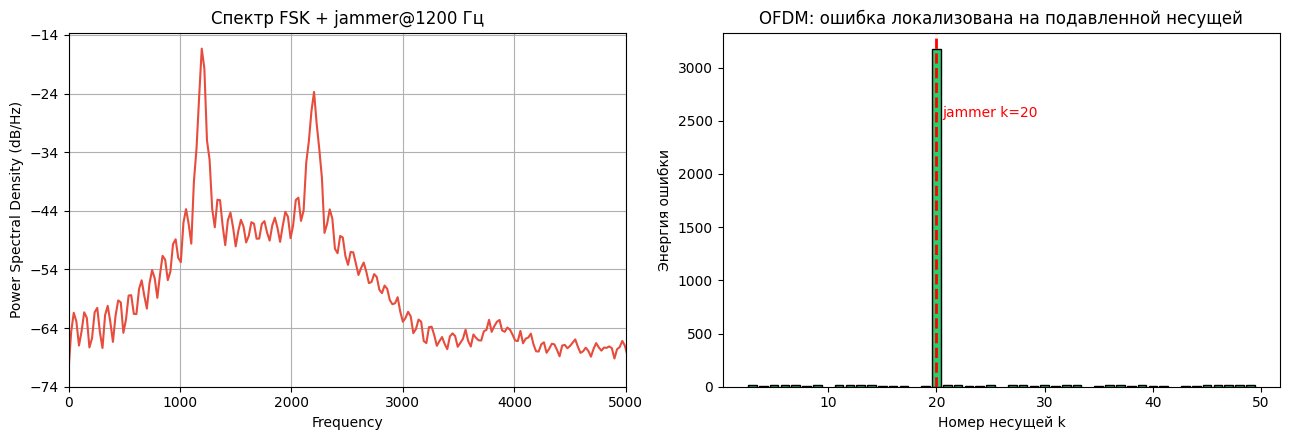

FSK теряет кадр целиком; OFDM теряет долю символов -> RS-FEC восстанавливает текст полностью.


In [7]:
snr = 20.0
# --- FSK под глушителем на mark ---
bits_f = m.packet_encode(b'jam test')
chirp = m.generate_chirp(200, 4000, 0.05)
sig_f = m.generate_fsk(bits_f, MARK, SPACE, BAUD, continuous_phase=True)
frame_f = np.concatenate([chirp, sig_f])
ch_f = m.simulate_channel(frame_f, snr_db=snr, reverb_amount=0.0, seed=1)
t = np.arange(len(ch_f)) / FS
ch_f_jam = ch_f + 0.9 * np.sin(2 * np.pi * 1200 * t).astype(np.float32)
corr, peak, _ = m.cross_correlate(ch_f_jam, chirp)
rx_f, _ = m.fsk_demodulate(ch_f_jam[peak + len(chirp):], MARK, SPACE, BAUD)
d_f = m.packet_decode(rx_f)
print(f'FSK + jammer@1200 Гц: найден={d_f["found"]}, CRC ok={d_f["crc_ok"]}')

# --- OFDM с глушителем на несущей k=20 ---
k_jam = 20
f_jam = k_jam * FS / cfg.fft_size
payload_rs = m.rs_encode(b'jam test', 10)  # RS(18,8): исправляет до 5 байт
bits_o = m.packet_encode(payload_rs)
sig_o = m.ofdm_modulate(bits_o, cfg)
pre = m.ofdm_sync_preamble(cfg)
frame_o = np.concatenate([pre, sig_o])
ch_o = m.simulate_channel(frame_o, snr_db=snr, reverb_amount=0.0, seed=1)
ch_o_jam = ch_o + 0.5 * np.sin(2 * np.pi * f_jam * t[:len(ch_o)]).astype(np.float32)
rx_o = ofdm_recv(ch_o_jam, cfg, len(sig_o))
d_o = m.packet_decode(rx_o)
ber_o = m.ber_measure(bits_o, rx_o[:len(bits_o)])['ber']
dec, nerr = m.rs_decode(d_o['payload'], 10) if d_o['found'] else (b'', -1)
rs_msg = 'ошибок не понадобилось' if nerr == 0 else f'исправил {nerr} байт'
print(f'OFDM + jammer@{f_jam:.0f} Гц (k={k_jam}): BER={ber_o:.4f}, CRC ok={d_o["crc_ok"]}, '
      f'RS: {rs_msg}, текст={dec!r}')

# карта ошибок по несущим OFDM: берём тело с той же точки, что и ofdm_recv
M, sc = m.schmidl_cox_sync(ch_o_jam, cfg)
lo = max(0, sc - 8)
seg = ch_o_jam[lo:sc + 8 + len(pre)]
c = np.correlate(seg, pre, mode='valid')
start = lo + int(np.argmax(np.abs(c))) + len(pre)
sym_len = cfg.fft_size + cfg.cp_len
body = ch_o_jam[start:start + int(np.floor(len(sig_o)/sym_len))*sym_len]
n_sym = len(body) // sym_len
err_per_carrier = np.zeros(len(cfg.data_carriers))
tx_syms = m.qam_map(bits_o + '0' * ((-len(bits_o)) % cfg.bits_per_symbol), cfg.qam_order)
for s in range(n_sym):
    seg = body[s*sym_len + cfg.cp_len:(s+1)*sym_len]
    spec = np.fft.fft(seg)[cfg.data_carriers]
    tx_chunk = tx_syms[s*len(cfg.data_carriers):(s+1)*len(cfg.data_carriers)]
    e = np.abs(spec - tx_chunk[:len(spec)]) ** 2
    err_per_carrier[:len(e)] += e

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].psd(ch_f_jam, NFFT=2048, Fs=FS, color='#e74c3c')
axes[0].set_title('Спектр FSK + jammer@1200 Гц')
axes[0].set_xlim(0, 5000)
axes[1].bar(cfg.data_carriers, err_per_carrier, color='#2ecc71', edgecolor='k')
axes[1].axvline(k_jam, color='r', ls='--', lw=2)
axes[1].text(k_jam + 0.5, err_per_carrier.max() * 0.8, f'jammer k={k_jam}', color='r')
axes[1].set_xlabel('Номер несущей k'); axes[1].set_ylabel('Энергия ошибки')
axes[1].set_title('OFDM: ошибка локализована на подавленной несущей')
plt.tight_layout(); plt.show()
print('FSK теряет кадр целиком; OFDM теряет долю символов -> RS-FEC восстанавливает текст полностью.')

## Выводы Lab 6

1. **Протокол**: преамбула+LEN+SEQ+CRC16 дают кадрирование, обнаружение ошибок и защиту от дублей.
2. **ARQ Stop-and-Wait** гарантирует доставку, но goodput рушится у границы устойчивости режима — там и нужно переключение.
3. **Probe-пакет** (двойное зондирование) оценивает SNR практически без смещения (после вычитания шумовой составляющей из суммы).
4. **Адаптивный выбор** держит огибающую максимального goodput: FSK в шуме, 64-QAM в чистом канале.
5. **Полный цикл** (RS+ARQ+OFDM) доставляет файл без единой ошибки; синхронизация двухступенчатая: Schmidl-Cox грубо, затем точная корреляция с известной преамбулой в окне +-8 отсчётов (реверб гуляет по пику S-C на единицы отсчётов).
6. **Jammer-тест**: FSK умирает от тона на mark-частоте, OFDM локализует урон на 1/42 несущих — и FEC добивает остаток.

**Протокол готов к реальному каналу**: телефон играет → микрофон ноутбука принимает.